## Exercises XP

### Exercise 1 : Visualizing the Distribution of CGPA

In [1]:
!unzip /content/drive/MyDrive/BootGenAI/student_mental_health.zip

Archive:  /content/drive/MyDrive/BootGenAI/student_mental_health.zip
  inflating: Student Mental health.csv  


In [4]:
import pandas as pd

df = pd.read_csv("/content/Student_Mental_health.csv")
print(df.head())
print(df.info())

        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      No                  Yes  

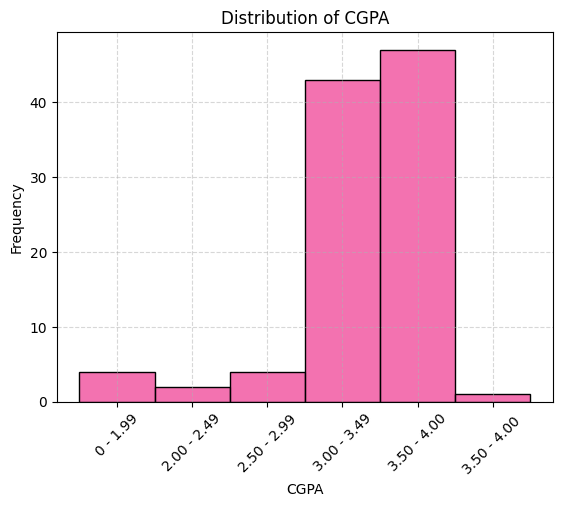

In [5]:
from matplotlib.typing import LineStyleType
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["What is your CGPA?"].sort_values() , bins=10 , color='#EF4396')
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.title("Distribution of CGPA")
plt.xticks(rotation=45)
plt.grid(True , alpha =0.5, linestyle='--')
plt.show()


### Exercise 2: Comparing Anxiety Levels Across Different Genders

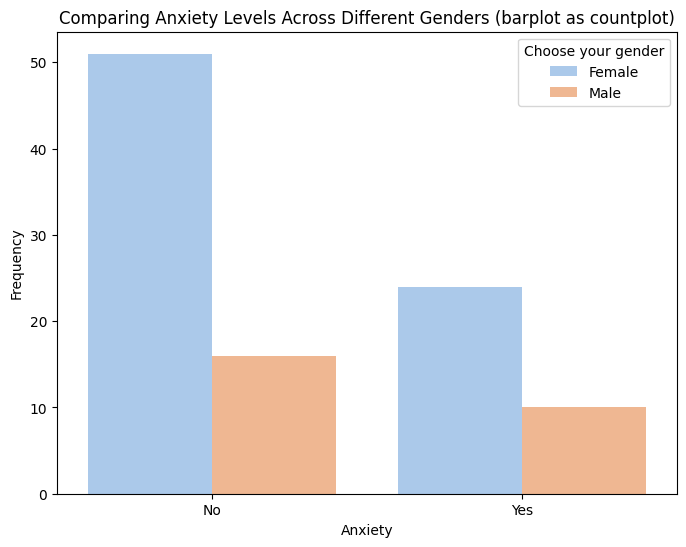

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ajouter une colonne "count" qui vaut 1 pour chaque ligne
df["count"] = 1

plt.figure(figsize=(8,6))
sns.barplot(x="Do you have Anxiety?", y="count", hue="Choose your gender",
            data=df, estimator=sum, palette="pastel")

plt.xlabel("Anxiety")
plt.ylabel("Frequency")
plt.title("Comparing Anxiety Levels Across Different Genders (barplot as countplot)")
plt.show()


### Exercise 3: Exploring the Relationship Between Age and Panic Attacks

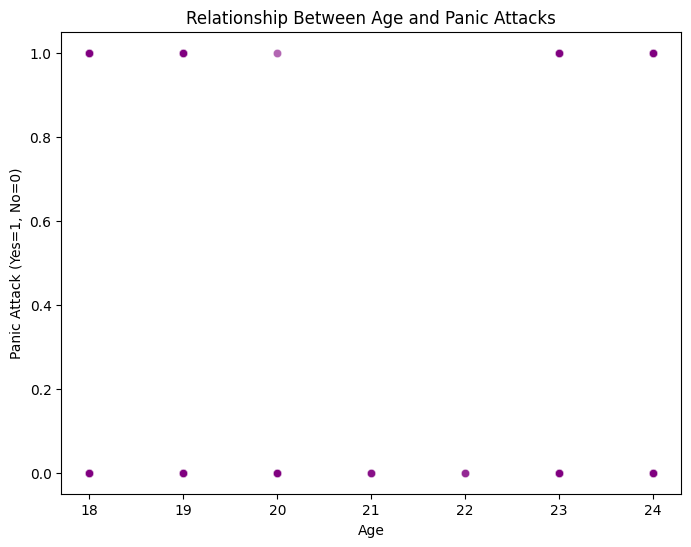

In [7]:
from os import replace
import matplotlib.pyplot as plt
import seaborn as sns

df["Panic_Attack_Num"] = df["Do you have Panic attack?"].map({"Yes":1, "No":0})

plt.figure(figsize=(8,6))
sns.scatterplot(x="Age", y="Panic_Attack_Num", data=df, color="purple", alpha=0.6)

plt.title("Relationship Between Age and Panic Attacks")
plt.xlabel("Age")
plt.ylabel("Panic Attack (Yes=1, No=0)")
plt.show()

### Exercise 4: Visualizing Pairwise Relationships with Seaborn Pair Plot

In [8]:
binary_map = {"Yes": 1, "No": 0}
df["Depression"] = df["Do you have Depression?"].map(binary_map)
df["Anxiety"] = df["Do you have Anxiety?"].map(binary_map)
df["Panic"] = df["Do you have Panic attack?"].map(binary_map)

In [9]:
cgpa_map = {
    "0.00 - 0.99": 0.5,
    "1.00 - 1.49": 1.25,
    "1.50 - 1.99": 1.75,
    "2.00 - 2.49": 2.25,
    "2.50 - 2.99": 2.75,
    "3.00 - 3.49": 3.25,
    "3.50 - 4.00": 3.75
}
df["CGPA"] = df["What is your CGPA?"].map(cgpa_map)


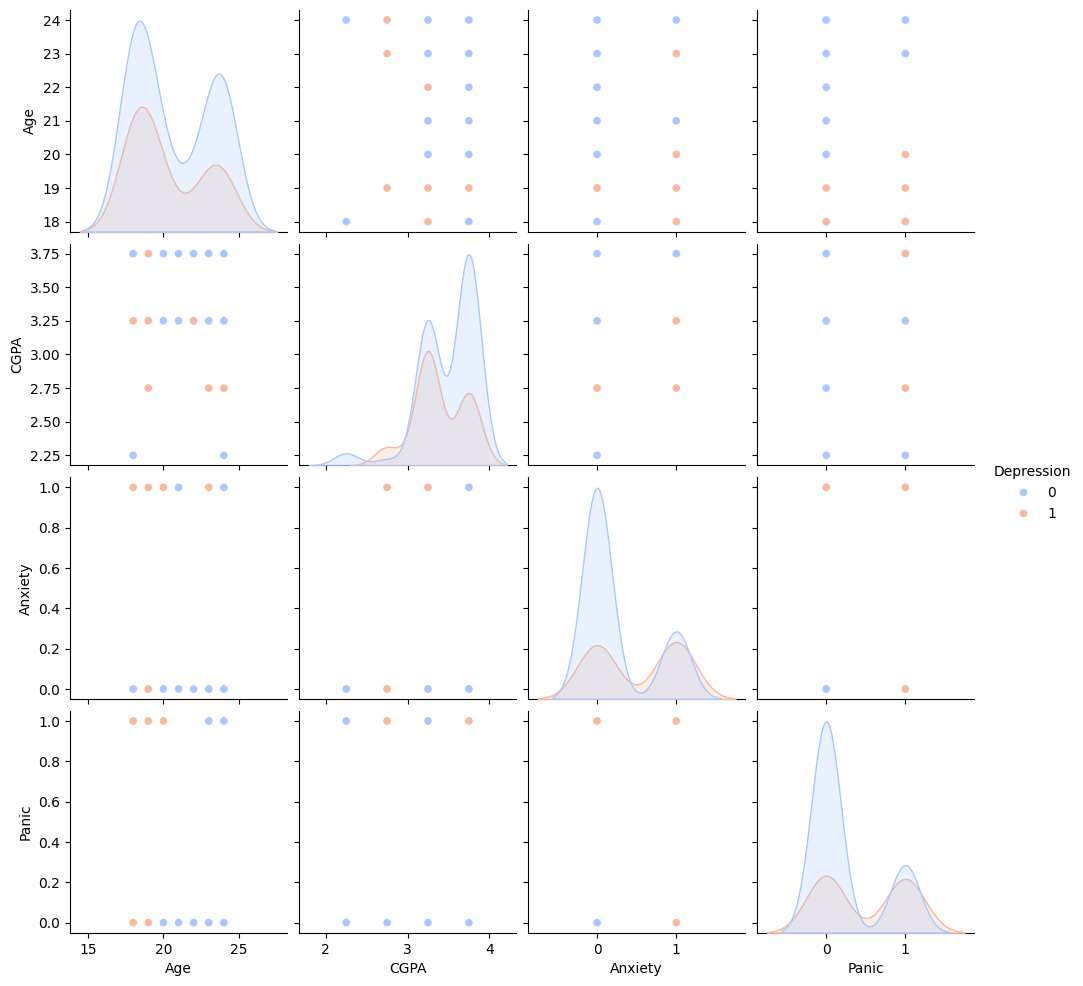

In [13]:
subset= df[["Age" , "CGPA","Depression", "Anxiety", "Panic"]]

sns.pairplot(subset, hue="Depression", diag_kind="kde", palette="coolwarm")
plt.show()

### Exercise 5: Creating a Heatmap to Visualize Correlations

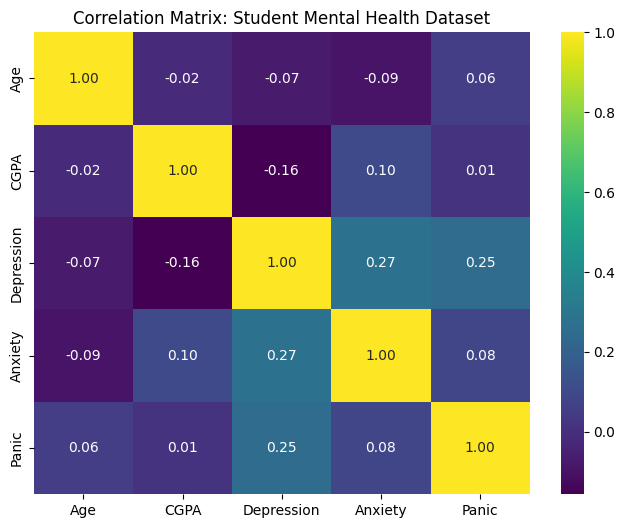

In [24]:
#Calculate correlation matrix
corr = subset.corr()

#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    cmap="viridis",   # color palette
    fmt=".2f"          # format numbers to 2 decimals
)
plt.title("Correlation Matrix: Student Mental Health Dataset")
plt.show()


### Exercise 6: Analyzing Distributions and Relationships Using FacetGrid

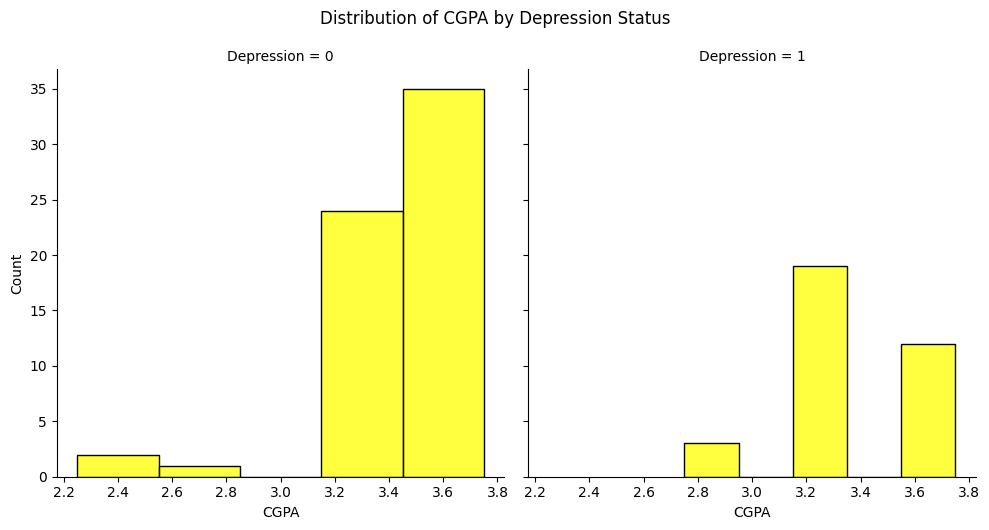

In [38]:
student_subset = subset[["CGPA","Depression"]]

g = sns.FacetGrid(df, col="Depression", height=5, aspect=1)
g.map(sns.histplot, "CGPA", bins=5, color="yellow")
g.set_axis_labels("CGPA", "Count")
g.set_titles(col_template="Depression = {col_name}")
plt.suptitle("Distribution of CGPA by Depression Status", y=1.05)
plt.show()